# Workflow: Feature Selection

**What is the motivation?**

Many Reinforcement Learning environments have high-dimensional observation spaces. With increasing state space dimensionality, learning an effective policy typically requires more and more data and time.

**What do we show here?**

Using `VeriGym`, we can easily specify which state features we want to exclude from our enviroment and automatically construct a reduced environment, including an abstraction mapping between the original and reduced observation spaces.

We use the Mujoco `"Ant-v5"` robotics environment from [`gymnasium`](https://gymnasium.farama.org/environments/mujoco/ant/) as an example. Its observation space has 105 dimension. The first 27 correspond to the torso pose and joint positions and velocities. The latter 78 dimensions correspond to the center of mass based external forces on the pody parts.

In this workflow notebook, we reduce the observation space to the first 27 dimensions by masking the remaining features. We then train a SAC agent using `stable_baselines3` on both the full and the reduced observation spaces.
We compare:
- the training performance on the original environment versus the reduced environment
- the performance of the policy trained on the reduced environment when evaluated on the original environment.

## Imports and helpers

In [1]:
# Imports
import gymnasium as gym
import matplotlib.pyplot as plt
import stable_baselines3 as sb3
import numpy as np
import os

# VeriGym
import verigym
import verigym.abstraction.feature_selection as fs
from verigym.frameworks.stable_baselines3.policy import SB3Policy

# Paths etc.
outpath = "../examples/workflow_fr_files/"

In [2]:
def train_with_sb3_sac(env, outpath):
    monitor_env = sb3.common.monitor.Monitor(env)
    if not os.path.exists(outpath):
        os.mkdir(outpath)
    save_path = outpath + "best/"
    if not os.path.exists(save_path):
        os.mkdir(save_path)
    log_path = outpath + "log/"
    if not os.path.exists(log_path):
        os.mkdir(log_path)
    model_path = outpath + "sac_model"

    eval_callback = sb3.common.callbacks.EvalCallback(monitor_env, 
                                                      best_model_save_path=save_path,
                                                      log_path=log_path,
                                                      eval_freq=10000,
                                                      deterministic=True,
                                                      render=False)
    
    model = sb3.SAC(
        policy="MlpPolicy",
        env=monitor_env,
        learning_rate=3e-4,
        buffer_size=1_000_000,
        batch_size=256,
        gamma=0.99,
        tau=0.005,
        train_freq=1,
        gradient_steps=1,
        ent_coef="auto",
        verbose=0
    )

    model.learn(total_timesteps=1_000_000,
                callback=eval_callback,
                progress_bar=True)
    
    model.save(model_path)
    monitor_env.close()

In [3]:
def plot_logged_data(log_paths, labels, key):
    logs = []
    for lp in log_paths:
        log = np.load(lp)
        logs.append(log[key])

    plt.title(f"Training {key} using SAC")
    for log, label in zip(logs, labels):
        plt.plot([i*10000 for i in range(len(log))], [np.mean(l) for l in log], label=label)
        plt.fill_between([i*10000 for i in range(len(log))], [np.mean(l)+np.std(l) for l in log], [np.mean(l) - np.std(l) for l in log], alpha=0.3)
    plt.ylabel(key)
    plt.xlabel("timesteps")
    plt.legend()
    plt.show()
    

In [4]:
def run_eval_episodes(env, policy):
    eval_rewards = []
    for _ in range(100):
        episode_reward = 0
        obs, _ = env.reset()

        while True:
            action = policy.get_action(obs)
            obs, rew, term, trunc, _ = env.step(action)
            
            episode_reward += rew
            if term or trunc:
                break

        eval_rewards.append(episode_reward)
    return eval_rewards

In [5]:
def plot_compare_policy_eval(rewards, labels):
    plt.title(f"Comparing policies in evaluation: {", ".join(labels)}")
    for i, (rew, label) in enumerate(zip(rewards, labels)):
        plt.scatter(i, np.mean(rew), label=label)
        plt.plot([i, i], [np.mean(rew) + np.std(rew), np.mean(rew) - np.std(rew)])
    plt.legend()
    plt.xticks([i for i in range(len(rewards))])
    plt.xlim(-0.5, len(rewards)-0.5)
    plt.show()

## Actual workflow

First, we load the standard `"Ant-v5"` environment into `VeriGym` using `verigym.GenerativeEnv.from_gymnasium`. 
This maintains all functionality of the original `gym` environment, and adds compatibility with additional `VeriGym` features.

In [6]:
ant_env = verigym.GenerativeEnv.from_gymnasium(
    gym.make("Ant-v5", render_mode="rgb_array")
)

Then, we specify the features to reduce (here: the 78 features that are not related to position or velocity). 
We use `VeriGym`'s feature selection with masking to remove the selected features.

In [7]:
reduce_features = [i for i in range(27, 105)]
fr_masked_env, abstraction_map = fs.state_feature_selection(original_env=ant_env, method="masking",
                                 reduce_indices=reduce_features)

For reference, we compare the original and reduced environments' action and observation spaces, as well as types.

Notice that the observation space dimensionality changes. Both environments' types are `VeriGym` native and `gym` compatible. Action spaces remain the same.

In [16]:
print("Original environment:")
print("type:", type(ant_env))
print("observation space: ", ant_env.observation_space)
print("action space: ", ant_env.action_space)
print()
print("Reduced environment:")
print("type:", type(fr_masked_env))
print("observation space: ", fr_masked_env.observation_space)
print("action space: ", fr_masked_env.action_space)

Original environment:
type: <class 'verigym.environments.generativeenv.GenerativeEnv_from_gym'>
observation space:  Box(-inf, inf, (105,), float64)
action space:  Box(-1.0, 1.0, (8,), float32)

Reduced environment:
type: <class 'verigym.abstraction.feature_selection.ReduceFeaturesWrapper'>
observation space:  Box(-inf, inf, (27,), float64)
action space:  Box(-1.0, 1.0, (8,), float32)


## Training code

We train models using the `stable_baselines3` implementation of `SAC` for `1.000.000` timesteps.

Note: Training took 70-85min on a 2023 MacBook Pro with 18GB RAM and M3 Chip. Therefore, the training lines are commented and we proceed with pre-saved models and logs.
To run training yourself, comment the lines back in.

In [9]:
#train_with_sb3_sac(ant_env, outpath+"full_env/")

In [10]:
#train_with_sb3_sac(fr_masked_env, outpath+"reduced_env/")

## Evaluation

Using the pre-trained models, we compare the following aspects: 
1. Training behavior (reward and episode length) between the agents trained on the environment with 105 dimensions (`full_model`) versus the reduced one (`reduced_model`).
2. Policy transfer by mapping the policy trained on the reduced environment back to the original observation space using `VeriGym`'s `SB3Policy` wrapper and the automatically generated `AbstractionMapper`.


In [11]:
full_model = sb3.SAC.load(outpath + "full_env/sac_model")
reduced_model = sb3.SAC.load(outpath + "reduced_env/sac_model")

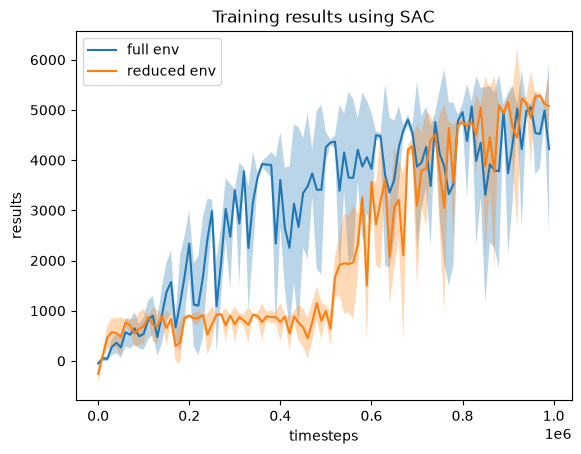

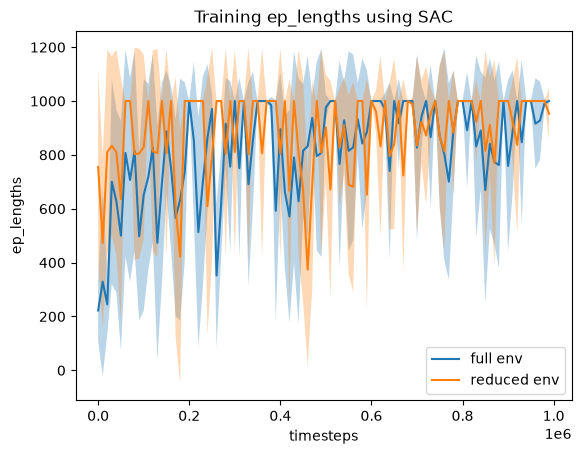

In [12]:
plot_logged_data([outpath + "full_env/log/evaluations.npz", outpath + "reduced_env/log/evaluations.npz"],
                    labels=["full env", "reduced env"], key="results")

plot_logged_data([outpath + "full_env/log/evaluations.npz", outpath + "reduced_env/log/evaluations.npz"],
                    labels=["full env", "reduced env"], key="ep_lengths")

Now, we compare policy performance by wrapping the stable baselines policies in to a `verigym.SB3Policy`. `full_policy` wraps the policy learned on the full observation space. `reduced_policy` wraps the policy learned on the reduced observation space.

Additionally, we can use the `abstraction_map` we got when we applied the feature reduction to have `VeriGym` map the policy from the reduced feature space to the original full feature space - we do that in `reduced_on_full_policy`.

In [13]:
full_policy = SB3Policy(full_model)
reduced_policy = SB3Policy(reduced_model)
reduced_on_full_policy = SB3Policy(reduced_model, abstraction_map)

We now evaluate the full policy and the reduced policy on the original full environment.

In [14]:
full_eval = run_eval_episodes(ant_env, full_policy)
reduced_on_full_eval = run_eval_episodes(ant_env, reduced_on_full_policy)
reduced_eval = run_eval_episodes(fr_masked_env, reduced_policy)

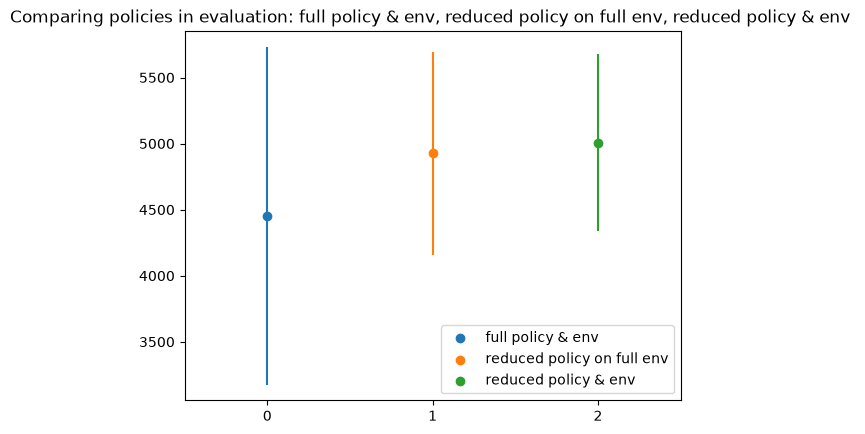

In [15]:
plot_compare_policy_eval([full_eval, reduced_on_full_eval, reduced_eval], ["full policy & env", "reduced policy on full env", "reduced policy & env "])